# Question 1 (10 Marks)¶
## Write a Python program with the following requirements:
### 1.Create a function that reads the Employee Database CSV file and returns a Pandas DataFrame with proper error handling for file operations
#### Uses try-except-finally block to ensure resources are properly managed
#### Handles FileNotFoundError with meaningful error messages

In [2]:
import numpy as np
import pandas as pd

In [42]:
def read_database(employee_database):
    try:
        df=pd.read_csv("employee_database(in).csv")
        print("File Uploaded Successfully")
        return df
    except FileNotFoundError:
        print(f"The File employee_database(in).csv was not found.Please check the File Path")
    finally:
        print("File Uploaded Completed")

In [43]:
r=read_database("employee_database(in).csv")

File Uploaded Successfully
File Uploaded Completed


In [3]:
df=pd.read_csv("employee_database(in).csv")
df

,EmployeeID,FirstName,LastName,Department,Designation,JoiningDate,Salary,Age,YearsOfExperience,Performance_Rating,Project_Count
0,1001,Arjun,Verma,Sales,Software Engineer,5/27/2016,1470473,50,1,3.57,14
1,1002,Sneha,Reddy,Sales,Software Engineer,9/15/2021,820082,26,10,3.35,11
2,1003,Rohan,Desai,Finance,Senior Manager,3/14/2021,1343361,28,25,4.58,1
3,1004,Divya,Sharma,Engineering,Manager,6/2/2022,2480943,57,6,3.61,4
4,1005,Vikram,Desai,Finance,Data Analyst,9/12/2016,2028235,48,5,2.40,2
...,...,...,...,...,...,...,...,...,...,...,...
1195,2196,Kavya,Patel,Engineering,Associate,12/18/2020,321576,39,23,4.74,8
1196,2197,Sneha,Verma,Finance,Associate,2/5/2023,1335865,39,5,1.35,13
1197,2198,Sneha,Gupta,Finance,Executive,4/18/2019,1628668,45,24,4.20,3
1198,2199,Vikram,Gupta,Finance,Data Analyst,6/29/2022,2486203,23,0,4.59,1


### 2.Create a custom exception class and a function that extracts employee information by ID
#### Implements custom exception if employee ID doesn't exist
#### Returns a formatted string: "FirstName LastName works in Department as Designation"
#### Uses try-except block to catch and raise this custom exception

In [45]:
class EmployeeNotFoundError(Exception):
    pass       

In [46]:
def get_info(df,emp_id):
    try:
        row=df[df['EmployeeID']==emp_id]
        
        if row.empty:
            raise EmployeeNotFoundError("Employee ID was not Found")

        row=row.iloc[0]
        return f"{row['FirstName']}{row['LastName']} works in {row['Department']} as {row['Designation']}"

    except EmployeeNotFoundError:
        raise 

In [47]:
try:
    print(get_info(df, 1050))
except EmployeeNotFoundError as e:
    print(e)


ArjunRao works in Engineering as Associate


### 3.Main execution:
#### Load the employee database
#### Extract and display information for Employee ID 1050
#### Demonstrate exception handling by attempting to fetch a non-existent Employee ID
##### Dataset: employee_database.csv

In [48]:
import csv
def load_employee_database():
    employees=[]
    with open("employee_database(in).csv","r")as file:
        reader=csv.DictReader(file)
        for row in reader:
            employees.append(row)
    return employees

In [49]:
def employee_id(employees,emp_id):
    for employee in employees:
        if int(employee["EmployeeID"])==emp_id:
            return employee
    return None 

In [50]:
employees=load_employee_database()
employee=employee_id(employees,1050)
if employee:
    print("Employee Found:")
    for key,value in employee.items():
        print(f"{key}:{value}")
else:
    print("Employee with ID 1050 was not Found")

Employee Found:
EmployeeID:1050
FirstName:Arjun
LastName:Rao
Department:Engineering
Designation:Associate
JoiningDate:11/16/2016
Salary:841220
Age:36
YearsOfExperience:0
Performance_Rating:2.4
Project_Count:12


In [51]:
def employee_id(employees,emp_id):
    for employee in employees:
        if int(employee["EmployeeID"])==emp_id:
            return employee
    raise EmployeeNotFoundError(f"Employee with ID {emp_id} not Found")

In [52]:
employees=load_employee_database()
try:
    employee=employee_id(employees, 999)
    print("Employee Found:")
    for key,value in employee.items():
        print(f"{key}:{value}")
except EmployeeNotFoundError as e:
    print("Exception Handled Successfully")
    print(e) 

Exception Handled Successfully
Employee with ID 999 not Found


In [53]:
def main():
    employees=load_employee_database()
    # existing emp
    try:
        employee=employee_id(employees, 1050)
        print("Employee Found:")
        for key,value in employee.items():
            print(f"{key}:{value}")
    except EmployeeNotFoundError as e:
        print(e) 
    print("\n-----------\n")
    # non-existing emp
    try:
        employee=employee_id(employees, 999)
        print("Employee Found:")
        for key,value in employee.items():
            print(f"{key}:{value}")
    except EmployeeNotFoundError as e:
        print("Exception Handled Successfully")
        print(e) 
main()

Employee Found:
EmployeeID:1050
FirstName:Arjun
LastName:Rao
Department:Engineering
Designation:Associate
JoiningDate:11/16/2016
Salary:841220
Age:36
YearsOfExperience:0
Performance_Rating:2.4
Project_Count:12

-----------

Exception Handled Successfully
Employee with ID 999 not Found


# Question 2 (10 Marks)
## Write a Python program with the following requirements:
### 1.Create a function that:
#### Validates name fields in a DataFrame
#### Combines first and last names using string concatenation
#### Uses if-elif-else to categorize based on:
#### Name length > 15 characters: "Long Name"
#### Contains numbers: "Invalid Format"
#### Otherwise: "Valid"
#### Returns tuples with ID, full name, and status

In [54]:
def validate_names(df):
    result=[]
    for i,row in df.iterrows():
        emp_id=row['EmployeeID']
        first_name=str(row['FirstName'])
        last_name=str(row['LastName'])
        full_name=first_name+ " "+last_name
        if len(full_name)>15:
            status="Long Name"
        elif any(char.isdigit() for char in full_name):
            status="Invalid Format"
        else:
            status="Valid"
    result.append((emp_id, full_name, status))
    return pd.DataFrame(result, columns=['EmployeeID', 'FullName', 'Status'])

In [55]:
df2=validate_names(df)
print(df2)

   EmployeeID     FullName Status
0        2200  Divya Verma  Valid


### 2.Create a function that:¶
#### Uses string methods (startswith, endswith, find) to filter names
#### Accepts a pattern parameter
#### Returns matching employees using list comprehension

In [56]:
def filter_name(df,pattern,method='find'):
    df['FullName'] = df['FirstName'] + " " + df['LastName']
    if method=='startswith':
        filter=df[df['FullName'].str.startswith(pattern)]
    elif method=='endswith':
        filter=df[df['FullName'].str.endswith(pattern)]
    elif method=='find':
        filter=df[df['FullName'].str.contains(pattern)]
    else:
        raise ValueError("Method must be 'startswith','endswith','find'")
    return list(zip(filter['EmployeeID'],filter['FullName']))   

In [57]:
print("Starts with 'A':", filter_name(df, 'Am', 'startswith'))
print("Ends with 'ir':", filter_name(df, 'ir', 'endswith'))
print("Contains 'ha':", filter_name(df, 'ha', 'find'))

Starts with 'A': [(1008, 'Amit Kumar'), (1017, 'Amit Singh'), (1039, 'Amit Desai'), (1044, 'Amit Patel'), (1046, 'Amit Kumar'), (1067, 'Amit Singh'), (1110, 'Amit Kumar'), (1113, 'Amit Reddy'), (1114, 'Amit Gupta'), (1133, 'Amit Desai'), (1138, 'Amit Kumar'), (1140, 'Amit Singh'), (1142, 'Amit Patel'), (1153, 'Amit Verma'), (1165, 'Amit Reddy'), (1191, 'Amit Gupta'), (1199, 'Amit Verma'), (1215, 'Amit Patel'), (1231, 'Amit Patel'), (1257, 'Amit Reddy'), (1262, 'Amit Kumar'), (1264, 'Amit Verma'), (1265, 'Amit Kumar'), (1283, 'Amit Gupta'), (1300, 'Amit Rao'), (1301, 'Amit Verma'), (1302, 'Amit Rao'), (1317, 'Amit Kumar'), (1319, 'Amit Kumar'), (1325, 'Amit Rao'), (1336, 'Amit Kumar'), (1341, 'Amit Kumar'), (1347, 'Amit Reddy'), (1359, 'Amit Singh'), (1361, 'Amit Verma'), (1368, 'Amit Reddy'), (1375, 'Amit Reddy'), (1382, 'Amit Reddy'), (1388, 'Amit Patel'), (1409, 'Amit Patel'), (1422, 'Amit Nair'), (1429, 'Amit Desai'), (1455, 'Amit Gupta'), (1462, 'Amit Verma'), (1465, 'Amit Gupta'),

### 3. Main execution:
#### Process all employee names
#### Filter by specific name patterns
#### Display validation counts using dictionaries
##### Dataset: employee_database.csv

In [58]:
df[['EmployeeID','FullName']]

,EmployeeID,FullName
0,1001,Arjun Verma
1,1002,Sneha Reddy
2,1003,Rohan Desai
3,1004,Divya Sharma
4,1005,Vikram Desai
...,...,...
1195,2196,Kavya Patel
1196,2197,Sneha Verma
1197,2198,Sneha Gupta
1198,2199,Vikram Gupta


In [59]:
def filter_name(df,pattern,method='find'):
    df['FullName'] = df['FirstName'] + " " + df['LastName']
    if method=='startswith':
        filter=df[df['FullName'].str.startswith(pattern)]
    elif method=='endswith':
        filter=df[df['FullName'].str.endswith(pattern)]
    elif method=='find':
        filter=df[df['FullName'].str.contains(pattern)]
    else:
        raise ValueError("Method must be 'startswith','endswith','find'")
    return list(zip(filter['EmployeeID'],filter['FullName'])) 

In [60]:
print("Starts with 'A':", filter_name(df, 'Po', 'startswith'))
print("Ends with 'ir':", filter_name(df, 'Rao', 'endswith'))
print("Contains 'ha':", filter_name(df, 'ra', 'find'))

Starts with 'A': [(1007, 'Pooja Gupta'), (1029, 'Pooja Nair'), (1036, 'Pooja Kumar'), (1056, 'Pooja Sharma'), (1058, 'Pooja Desai'), (1076, 'Pooja Reddy'), (1080, 'Pooja Kumar'), (1083, 'Pooja Kumar'), (1094, 'Pooja Rao'), (1118, 'Pooja Kumar'), (1120, 'Pooja Reddy'), (1145, 'Pooja Singh'), (1150, 'Pooja Rao'), (1151, 'Pooja Singh'), (1169, 'Pooja Kumar'), (1179, 'Pooja Singh'), (1200, 'Pooja Desai'), (1210, 'Pooja Desai'), (1235, 'Pooja Gupta'), (1263, 'Pooja Patel'), (1282, 'Pooja Verma'), (1286, 'Pooja Nair'), (1385, 'Pooja Verma'), (1387, 'Pooja Desai'), (1396, 'Pooja Gupta'), (1398, 'Pooja Verma'), (1406, 'Pooja Sharma'), (1408, 'Pooja Kumar'), (1414, 'Pooja Kumar'), (1431, 'Pooja Reddy'), (1433, 'Pooja Verma'), (1434, 'Pooja Patel'), (1438, 'Pooja Verma'), (1461, 'Pooja Nair'), (1467, 'Pooja Verma'), (1469, 'Pooja Nair'), (1471, 'Pooja Rao'), (1478, 'Pooja Patel'), (1479, 'Pooja Rao'), (1493, 'Pooja Patel'), (1504, 'Pooja Desai'), (1505, 'Pooja Gupta'), (1512, 'Pooja Singh'), (15

In [61]:
def validate_name(full_name):
    full_name = str(full_name)

    if len(full_name) > 15:
        return "Long Name"
    elif any(char.isdigit() for char in full_name):
        return "Invalid Format"
    else:
        return "Valid"
df['FullName'] = df['FirstName'].astype(str) + " " + df['LastName'].astype(str)
df['Status'] = df['FullName'].apply(validate_name)

print(df[['EmployeeID', 'FullName', 'Status']])


      EmployeeID      FullName Status
0           1001   Arjun Verma  Valid
1           1002   Sneha Reddy  Valid
2           1003   Rohan Desai  Valid
3           1004  Divya Sharma  Valid
4           1005  Vikram Desai  Valid
...          ...           ...    ...
1195        2196   Kavya Patel  Valid
1196        2197   Sneha Verma  Valid
1197        2198   Sneha Gupta  Valid
1198        2199  Vikram Gupta  Valid
1199        2200   Divya Verma  Valid

[1200 rows x 3 columns]


In [62]:
status_counts=df['Status'].value_counts().to_dict()
status_counts

{'Valid': 1200}

In [63]:
def main():
    # dataset
    df=pd.read_csv("employee_database(in).csv")
    # FullName
    df['FullName'] = df['FirstName'].astype(str) + " " + df['LastName'].astype(str)
    # filter names
    print("Starts with 'Po':", filter_name(df, 'Po', 'startswith'))
    print("Ends with 'Rao':", filter_name(df, 'Rao', 'endswith'))
    print("Contains 'ra':", filter_name(df, 'ra', 'find'))
    # Validate names
    df['Status'] = df['FullName'].apply(validate_name)
    # Display results
    print("\nEmployee Name Validation:")
    print(df[['EmployeeID', 'FullName', 'Status']])
    # Display validation counts using dictionary
    status_counts = df['Status'].value_counts().to_dict()
    print("\nValidation Counts:")
    print(status_counts)

In [64]:
main()

Starts with 'Po': [(1007, 'Pooja Gupta'), (1029, 'Pooja Nair'), (1036, 'Pooja Kumar'), (1056, 'Pooja Sharma'), (1058, 'Pooja Desai'), (1076, 'Pooja Reddy'), (1080, 'Pooja Kumar'), (1083, 'Pooja Kumar'), (1094, 'Pooja Rao'), (1118, 'Pooja Kumar'), (1120, 'Pooja Reddy'), (1145, 'Pooja Singh'), (1150, 'Pooja Rao'), (1151, 'Pooja Singh'), (1169, 'Pooja Kumar'), (1179, 'Pooja Singh'), (1200, 'Pooja Desai'), (1210, 'Pooja Desai'), (1235, 'Pooja Gupta'), (1263, 'Pooja Patel'), (1282, 'Pooja Verma'), (1286, 'Pooja Nair'), (1385, 'Pooja Verma'), (1387, 'Pooja Desai'), (1396, 'Pooja Gupta'), (1398, 'Pooja Verma'), (1406, 'Pooja Sharma'), (1408, 'Pooja Kumar'), (1414, 'Pooja Kumar'), (1431, 'Pooja Reddy'), (1433, 'Pooja Verma'), (1434, 'Pooja Patel'), (1438, 'Pooja Verma'), (1461, 'Pooja Nair'), (1467, 'Pooja Verma'), (1469, 'Pooja Nair'), (1471, 'Pooja Rao'), (1478, 'Pooja Patel'), (1479, 'Pooja Rao'), (1493, 'Pooja Patel'), (1504, 'Pooja Desai'), (1505, 'Pooja Gupta'), (1512, 'Pooja Singh'), (1

# Question 3 (10 Marks)
## Write a Python program with the following requirements:
### 1.Create a class that accepts a Pandas DataFrame in its constructor

In [65]:
class Employee:
    def __init__(self,df):
        self.df=df

### 2.Implement methods that:
#### Return a dictionary with department names as keys and values containing total employees,average salary, and average performance rating
#### Return a dictionary with department names as keys and highest-paid employee names as values

In [66]:
class Employee:
    def __init__(self,df):
        self.df=df
    def department_stats(self):
        result={}
        for dept,group in self.df.groupby('Department'):
            result[dept]={"TotalEmployees":len(group),
                          "AverageSalary":group['Salary'].mean().round(2),
                          "AveragePerformance":group['Performance_Rating'].mean().round(2)}
        return result
    def high_paid(self):
        res={}
        for dept,group in self.df.groupby('Department'):
            highest_paid=group.loc[group['Salary'].idxmax()]
            full_name=highest_paid['FirstName']+" "+highest_paid['LastName']
            res[dept]=full_name
        return res

### 3.Use NumPy for numerical calculations (mean operations)

In [67]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols

Index(['EmployeeID', 'Salary', 'Age', 'YearsOfExperience',
       'Performance_Rating', 'Project_Count'],
      dtype='object')

In [68]:
mean=np.mean(df.select_dtypes(include='number'),axis=0)
mean.round(2)

EmployeeID               1600.50
Salary                1396182.55
Age                        40.56
YearsOfExperience          14.62
Performance_Rating          3.04
Project_Count               7.60
dtype: float64

### 4. Main execution:
#### Instantiate the class with employee data
#### Display results from both methods
##### Dataset: employee_database.csv

In [69]:
class EmployeeAnalytics:
    def __init__(self, df):
        self.df = df

In [70]:
e=Employee(df)
dept_stats=e.department_stats()
dept_stats

{'Engineering': {'TotalEmployees': 203,
  'AverageSalary': np.float64(1418513.57),
  'AveragePerformance': np.float64(3.03)},
 'Finance': {'TotalEmployees': 209,
  'AverageSalary': np.float64(1377834.16),
  'AveragePerformance': np.float64(3.01)},
 'HR': {'TotalEmployees': 214,
  'AverageSalary': np.float64(1364483.24),
  'AveragePerformance': np.float64(3.0)},
 'Marketing': {'TotalEmployees': 204,
  'AverageSalary': np.float64(1427740.71),
  'AveragePerformance': np.float64(2.98)},
 'Operations': {'TotalEmployees': 194,
  'AverageSalary': np.float64(1438567.57),
  'AveragePerformance': np.float64(3.15)},
 'Sales': {'TotalEmployees': 176,
  'AverageSalary': np.float64(1347459.34),
  'AveragePerformance': np.float64(3.08)}}

In [71]:
e=Employee(df)
high=e.high_paid()
high

{'Engineering': 'Sneha Reddy',
 'Finance': 'Pooja Kumar',
 'HR': 'Kavya Verma',
 'Marketing': 'Rohan Singh',
 'Operations': 'Kavya Kumar',
 'Sales': 'Arjun Reddy'}

In [72]:
class EmployeeAnalytics:
    def __init__(self,df):
        self.df=df
    def department_stats(self):
        result={}
        for dept,group in self.df.groupby('Department'):
            result[dept]={"TotalEmployees":len(group),
                          "AverageSalary":group['Salary'].mean().round(2),
                          "AveragePerformance":group['Performance_Rating'].mean().round(2)}
        return result
    def high_paid(self):
        res={}
        for dept,group in self.df.groupby('Department'):
            highest_paid=group.loc[group['Salary'].idxmax()]
            full_name=highest_paid['FirstName']+" "+highest_paid['LastName']
            res[dept]=full_name
        return res


In [73]:
def main():
    analytics=EmployeeAnalytics(df)
    dept=analytics.department_stats()
    print("Department Statistics:")
    print(dept)
    print("\n-----------\n")
    highest_paid=analytics.high_paid()
    print("Highest paid by each department:")
    print(highest_paid)

In [74]:
main()

Department Statistics:
{'Engineering': {'TotalEmployees': 203, 'AverageSalary': np.float64(1418513.57), 'AveragePerformance': np.float64(3.03)}, 'Finance': {'TotalEmployees': 209, 'AverageSalary': np.float64(1377834.16), 'AveragePerformance': np.float64(3.01)}, 'HR': {'TotalEmployees': 214, 'AverageSalary': np.float64(1364483.24), 'AveragePerformance': np.float64(3.0)}, 'Marketing': {'TotalEmployees': 204, 'AverageSalary': np.float64(1427740.71), 'AveragePerformance': np.float64(2.98)}, 'Operations': {'TotalEmployees': 194, 'AverageSalary': np.float64(1438567.57), 'AveragePerformance': np.float64(3.15)}, 'Sales': {'TotalEmployees': 176, 'AverageSalary': np.float64(1347459.34), 'AveragePerformance': np.float64(3.08)}}

-----------

Highest paid by each department:
{'Engineering': 'Sneha Reddy', 'Finance': 'Pooja Kumar', 'HR': 'Kavya Verma', 'Marketing': 'Rohan Singh', 'Operations': 'Kavya Kumar', 'Sales': 'Arjun Reddy'}


# Question 4 (10 Marks)
## Write a Python program with the following requirements:
### 1. Load employee data and create NumPy arrays for:
#### Salary data
#### Years of experience
#### Employee age

In [75]:
salary=df['Salary'].to_numpy()
salary

array([1470473,  820082, 1343361, ..., 1628668, 2486203, 2332342])

In [76]:
experience=df['YearsOfExperience'].to_numpy()
experience

array([ 1, 10, 25, ..., 24,  0, 24])

In [77]:
age=df['Age'].to_numpy()
age

array([50, 26, 28, ..., 45, 23, 41])

# 2.Perform NumPy operations:
## Calculate mean, median, standard deviation, minimum, and maximum for salaries
### Create a normalized salary array using (x - min)/(max - min) formula
### Use np.digitize() to create salary brackets:
#### Bracket 1: < 500K
#### Bracket 2: 500K-1M
#### Bracket 3: 1M-1.5M
#### Bracket 4: > 1.5M

In [78]:
mean_salary = np.mean(salary)
mean_salary.round(2)

np.float64(1396182.55)

In [79]:
median_salary = np.median(salary)
median_salary

np.float64(1365412.5)

In [80]:
std_salary = np.std(salary)
std_salary.round(2)

np.float64(640463.16)

In [81]:
min_salary = np.min(salary)
min_salary 

np.int64(300215)

In [82]:
max_salary = np.max(salary)
max_salary 

np.int64(2494358)

In [83]:
normalized_salary=(salary-min(salary))/(max(salary)-min(salary))
normalized_salary

array([0.53335539, 0.23693396, 0.47542298, ..., 0.60545416, 0.99628329,
       0.92615978])

In [84]:
np.digitize?

Signature:       np.digitize(x, bins, right=False)
Call signature:  np.digitize(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function digitize at 0x0000024AF81F4EA0>
File:            c:\users\user 10\anaconda3\lib\site-packages\numpy\lib\_function_base_impl.py
Docstring:      
Return the indices of the bins to which each value in input array belongs.

=========  =============  ============================
`right`    order of bins  returned index `i` satisfies
=========  =============  ============================
``False``  increasing     ``bins[i-1] <= x < bins[i]``
``True``   increasing     ``bins[i-1] < x <= bins[i]``
``False``  decreasing     ``bins[i-1] > x >= bins[i]``
``True``   decreasing     ``bins[i-1] >= x > bins[i]``
=========  =============  ============================

If values in `x` are beyond the bounds of `bins`, 0 or ``len(bins)`` is
returned as appropriate.

Parameters
----------
x : array_like
    Input array to be binned. Prior to

In [85]:
bins=[0,500000,1000000,1500000]
df['Salary_Bracket']=np.digitize(df['Salary'].to_numpy(),bins)

In [86]:
df[['Salary','Salary_Bracket']]

,Salary,Salary_Bracket
0,1470473,3
1,820082,2
2,1343361,3
3,2480943,4
4,2028235,4
...,...,...
1195,321576,1
1196,1335865,3
1197,1628668,4
1198,2486203,4


## 3.Create a function that:
### Calculates correlation between two arrays using NumPy
### Returns comprehensive statistical measures as a dictionary
#### Uses NumPy broadcasting for vectorized operations

In [87]:
def correlation_stats(x,y):
    x=np.asarray(x,float)
    y=np.asarray(y,float)
    correlation=np.corrcoef(x,y)[0,1]
    return{
    "mean_x":np.mean(x),
    "mean_y":np.mean(y),
    "std_x":np.std(x),
    "std_y":np.std(y),
    "variance_x":np.var(x),
    "variance_y":np.var(y),
    # broadcasting
    "covariance":np.mean((x-x.mean())*(y-y.mean())),
    "correlation":correlation
    }

In [88]:
x = [10, 20, 30, 40, 50]
y = [15, 25, 35, 45, 60]
result=correlation_stats(x,y)
result

{'mean_x': np.float64(30.0),
 'mean_y': np.float64(36.0),
 'std_x': np.float64(14.142135623730951),
 'std_y': np.float64(15.620499351813308),
 'variance_x': np.float64(200.0),
 'variance_y': np.float64(244.0),
 'covariance': np.float64(220.0),
 'correlation': np.float64(0.995893206467704)}

## 4. Error handling:
### Validate array dimensions
#### Handle division by zero scenarios

In [89]:
def correlation_stat(x,y):
    try:
        x=np.asarray(x,float)
        y=np.asarray(y,float)

        if x.ndim!=1 or y.ndim!=1 or x.size!=y.size or x.size==0:
            return {"error": "Invalid input dimensions"}

        std_x=np.std(x)
        std_y=np.std(y)
        if std_x==0 or std_y==0:
            return {"error":"Standard deviation is zero"}

        covariance=np.mean((x-x.mean())*(y-y.mean()))
        correlation=covariance/(std_x*std_y)

        return {"correlation":correlation}
    
    except Exception as e:
        return {"error":str(e)}

In [90]:
print(correlation_stat([1, 2, 3, 4], [2, 4, 6, 8]))

{'correlation': np.float64(0.9999999999999998)}


In [91]:
print(correlation_stat([1, 2, 3], [1, 2]))

{'error': 'Invalid input dimensions'}


In [92]:
print(correlation_stat([5, 5, 5], [1, 2, 3]))

{'error': 'Standard deviation is zero'}


In [93]:
print(correlation_stat([], []))

{'error': 'Invalid input dimensions'}


In [94]:
my_result = correlation_stat([10, 20, 30], [15, 25, 35])
numpy_result = np.corrcoef([10,20,30], [15,25,35])[0,1]

print(my_result)
print(numpy_result)


{'correlation': np.float64(1.0)}
1.0


## 5. Main execution:
### Display all salary statistics
### Show bracket distribution using np.bincount
### Display correlation analysis
##### Dataset: employee_database.csv

In [95]:
salary=df['Salary'].to_numpy()
salary_stats={
    "mean":np.mean(salary),"median":np.median(salary),
    "std":np.std(salary),"min":np.min(salary),"max":np.max(salary)}
salary_stats    

{'mean': np.float64(1396182.5541666667),
 'median': np.float64(1365412.5),
 'std': np.float64(640463.1618102965),
 'min': np.int64(300215),
 'max': np.int64(2494358)}

In [96]:
bins=[500000,1000000,1500000]
salary_brackets=np.digitize(salary,bins)
salary_brackets

array([2, 1, 2, ..., 3, 3, 3])

In [97]:
brackets_counts=np.bincount(salary_brackets)
brackets_counts

array([105, 277, 279, 539])

In [98]:
print("\nSalary Bracket Distribution:")
print("< 50K        :", brackets_counts[0])
print("50K - 1L     :", brackets_counts[1])
print("1L - 1.5L    :", brackets_counts[2])
print("> 1.5L       :", brackets_counts[3])


Salary Bracket Distribution:
< 50K        : 105
50K - 1L     : 277
1L - 1.5L    : 279
> 1.5L       : 539


In [99]:
np.bincount?

Call signature:  np.bincount(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <built-in function bincount>
Docstring:      
bincount(x, /, weights=None, minlength=0)

Count number of occurrences of each value in array of non-negative ints.

The number of bins (of size 1) is one larger than the largest value in
`x`. If `minlength` is specified, there will be at least this number
of bins in the output array (though it will be longer if necessary,
depending on the contents of `x`).
Each bin gives the number of occurrences of its index value in `x`.
If `weights` is specified the input array is weighted by it, i.e. if a
value ``n`` is found at position ``i``, ``out[n] += weight[i]`` instead
of ``out[n] += 1``.

Parameters
----------
x : array_like, 1 dimension, nonnegative ints
    Input array.
weights : array_like, optional
    Weights, array of the same shape as `x`.
minlength : int, optional
    A minimum number of bins for the output array.

    .. versionadde

In [100]:
# correlation 
x=df['Salary'].to_numpy()
y=df['YearsOfExperience'].to_numpy()
result=correlation_stat(x,y)
result

{'correlation': np.float64(-0.024639531330441795)}

# Question 5 (10 Marks)
## Write a Python program with the following requirements:
## 1. Create a base class with:
### Private attributes using name mangling
### Public accessor methods
### A protected method that calculates a 10% bonus

In [128]:
class Employee:
    def __init__(self,emp_id,name,salary):
        self.__emp_id =emp_id 
        self.__name=name
        self.__salary=salary
        self._salary=salary*0.10
    def get_id(self):
        return self.__emp_id
    def get_name(self):
        return self.__name
    def get_salary(self):
        return self.__salary
    def set_salary(self,salary):
        if salary>0:
            self.__salary=salary
        else:
            print("Invalid Salary")
    def calculate_bonus(self):
        return self.__salary*0.10        

In [129]:
e=Employee(7,"Dhoni",50000)
print(e.get_id())
print(e.get_name())
print(e.get_salary())
print(e.calculate_bonus())

7
Dhoni
50000
5000.0


## 2.Create two derived classes that:
### Inherit from the base class
### Have additional specific attributes
### Override the bonus calculation method (15% and 12% respectively)
### Include role-specific methods

In [133]:
class Manager(Employee):
    def __init__(self,emp_id,name,salary,team_size):
        super().__init__(emp_id,name,salary)
        self.team_size=team_size
    def calculate_bonus(self):
        return self.get_salary()*0.15
    def manage_team(self):
        return f"Managing a team of {self.team_size} employees"

In [137]:
class Developer(Employee):
    def __init__(self,emp_id,name,salary,program):
        super().__init__(emp_id,name,salary)
        self.program=program
    def calculate_bonus(self):
        return self.get_salary()*0.12
    def write_code(self):
        return f"Write a code in {self.program}"

In [139]:
mgr = Manager(3,"Sree", 80000, 5)
dev = Developer(8,"Ram", 60000, "Python")

print("Manager Bonus:", mgr.calculate_bonus())
print(mgr.manage_team())

print("Developer Bonus:", dev.calculate_bonus())
print(dev.write_code())

Manager Bonus: 12000.0
Managing a team of 5 employees
Developer Bonus: 7200.0
Write a code in Python


## 3.Create a function that:
### Accepts any employee object
### Displays employee ID, salary, and calculated bonus
### Uses isinstance() to identify and display object type
### Works with both derived classes (polymorphism)

In [147]:
def display_employee(e):
    print("ID:",e.get_id())
    print("Salary:",e.get_salary())

    bonus=e.calculate_bonus()
    print("Bonus:",bonus)

    if isinstance(e,Manager):
        print("Type:Manager")
    elif isinstance(e,Developer):
        print("Type:Developer")
    elif isinstance(e,Employee):
        print("Type:Employee")
    else:
        print("Type:Unknown")


In [148]:
mgr = Manager(101, "Sree", 80000, 5)
display_employee(mgr)

ID: 101
Salary: 80000
Bonus: 12000.0
Type:Manager


In [149]:
dev = Developer(102, "Ram", 60000, "Python")
display_employee(dev)

ID: 102
Salary: 60000
Bonus: 7200.0
Type:Developer


## 4. Main execution:
### Create multiple instances from different employee data
### Demonstrate proper encapsulation
### Show inheritance and polymorphism with at least 3 different objects
##### Dataset: employee_database.csv, manager_database.csv

In [151]:
e1=Employee(7,"Dhoni",700000)
e2=Manager(18,"Virat",180000,11)
e3=Developer(45,"Rohit",450000,'SQL')
print(e1.get_id())
print(e2.get_name())
print(e3.get_salary())
e2.set_salary(810000)
print("Update Salary:",e2.get_salary())

7
Virat
450000
Update Salary: 810000


In [153]:
employees=[e1,e2,e3]
for i in employees:
    print("Employee Details:")
    display_employee(i)

Employee Details:
ID: 7
Salary: 700000
Bonus: 70000.0
Type:Employee
Employee Details:
ID: 18
Salary: 810000
Bonus: 121500.0
Type:Manager
Employee Details:
ID: 45
Salary: 450000
Bonus: 54000.0
Type:Developer


# Question 6 (10 Marks)
## Write a Python program with the following requirements:
## 1. Create a function that:
### Extracts employee data as tuples containing EmployeeID, FirstName, Performance_Rating, and Department
### Iterates through tuples using for loops
### Uses if-elif-else statements to categorize based on performance rating:
#### = 4.5: "Excellent"
#### 3.5-4.5: "Good"
#### 2.5-3.5: "Average"
#### < 2.5: "Needs Improvement"
### Returns a list of dictionaries with id, name, and category

In [158]:
def perform_emp(df):
    result=[]
    for emp in df:
        'EmployeeID', 'FirstName','LastName','Performance_Rating','Department'

        if 'Performance_Rating'>=4.5:
            category="Excellent"
        elif 3.5 <='Performance_Rating'<4.5:
            category="Good"
        elif 2.5 <= 'Performance_Rating'<3.5:
            category="Average"
        else:
            category="Needs Improvement"

        emp_dict={ "id":'EmployeeID',"name":'FullName',"category":category}
        result.append(emp_dict)
    return result

## 2 . Create a function that:
### Accepts a list and a count parameter
### Sorts and returns top N items using list slicing
### Handles edge cases where requested count exceeds available items

In [160]:
def top_n_items(data_list,count):
    if not data_list or count<=0:
        return []
    sorted_list=sorted(data_list,reverse=True)
    if count>len(sorted_list):
        count=len(sorted_list)
    return sorted_list[:count]

In [161]:
n = [45, 12, 89, 23, 67, 5]

top_items = top_n_items(n, 3)
print("Top 3 items:", top_items)

top_items_exceed = top_n_items(n, 10)
print("Top items when count exceeds list size:", top_items_exceed)

Top 3 items: [89, 67, 45]
Top items when count exceeds list size: [89, 67, 45, 23, 12, 5]


## 3. Main execution:
### Process all employees
### Display top 15 performers
#### Calculate and display mean and standard deviation of performance ratings using NumPy
##### Dataset: employee_database.csv

In [162]:
print("All Employees:")
df

All Employees:


,EmployeeID,FirstName,LastName,Department,Designation,JoiningDate,Salary,Age,YearsOfExperience,Performance_Rating,Project_Count,FullName,Status,Salary_Bracket
0,1001,Arjun,Verma,Sales,Software Engineer,5/27/2016,1470473,50,1,3.57,14,Arjun Verma,Valid,3
1,1002,Sneha,Reddy,Sales,Software Engineer,9/15/2021,820082,26,10,3.35,11,Sneha Reddy,Valid,2
2,1003,Rohan,Desai,Finance,Senior Manager,3/14/2021,1343361,28,25,4.58,1,Rohan Desai,Valid,3
3,1004,Divya,Sharma,Engineering,Manager,6/2/2022,2480943,57,6,3.61,4,Divya Sharma,Valid,4
4,1005,Vikram,Desai,Finance,Data Analyst,9/12/2016,2028235,48,5,2.40,2,Vikram Desai,Valid,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2196,Kavya,Patel,Engineering,Associate,12/18/2020,321576,39,23,4.74,8,Kavya Patel,Valid,1
1196,2197,Sneha,Verma,Finance,Associate,2/5/2023,1335865,39,5,1.35,13,Sneha Verma,Valid,3
1197,2198,Sneha,Gupta,Finance,Executive,4/18/2019,1628668,45,24,4.20,3,Sneha Gupta,Valid,4
1198,2199,Vikram,Gupta,Finance,Data Analyst,6/29/2022,2486203,23,0,4.59,1,Vikram Gupta,Valid,4


In [165]:
top_15=df.sort_values(by='Performance_Rating',ascending=False)
top_15.head(15)

,EmployeeID,FirstName,LastName,Department,Designation,JoiningDate,Salary,Age,YearsOfExperience,Performance_Rating,Project_Count,FullName,Status,Salary_Bracket
1066,2067,Rajesh,Nair,Finance,Manager,6/14/2024,1146822,32,10,5.00,5,Rajesh Nair,Valid,3
664,1665,Sneha,Gupta,Marketing,Software Engineer,7/9/2022,2372171,22,14,5.00,11,Sneha Gupta,Valid,4
644,1645,Pooja,Gupta,Operations,Associate,10/1/2017,553078,51,14,4.99,14,Pooja Gupta,Valid,2
1118,2119,Rajesh,Patel,Sales,Software Engineer,10/22/2016,2194420,39,3,4.99,2,Rajesh Patel,Valid,4
300,1301,Amit,Verma,Marketing,Manager,12/2/2022,1718767,42,19,4.99,10,Amit Verma,Valid,4
166,1167,Kavya,Sharma,Marketing,Software Engineer,8/2/2021,1128416,49,8,4.99,3,Kavya Sharma,Valid,3
961,1962,Pooja,Singh,HR,Manager,1/9/2023,1747922,48,27,4.98,9,Pooja Singh,Valid,4
41,1042,Sneha,Rao,Engineering,Manager,12/10/2021,2346719,45,12,4.97,9,Sneha Rao,Valid,4
653,1654,Priya,Kumar,HR,Data Analyst,1/19/2023,583816,48,26,4.97,12,Priya Kumar,Valid,2
1013,2014,Priya,Nair,Operations,Manager,6/26/2015,377994,54,2,4.97,12,Priya Nair,Valid,1


In [166]:
performance=df['Performance_Rating'].to_numpy()
performance

array([3.57, 3.35, 4.58, ..., 4.2 , 4.59, 4.76])

In [169]:
mean=np.mean(performance)
mean.round(2)

np.float64(3.04)

In [171]:
std=np.std(performance)
std.round(2)

np.float64(1.17)

# Question 7 (10 Marks)
## Write a Python program with the following requirements:
## 1. Create three separate functions:
### Function 1: Accepts keyword arguments for filtering
#### Supports multiple filter conditions
#### Uses conditional logic
#### Returns filtered DataFrame

In [18]:
def filter_emp(df,**filter):
    filtered_df=df
    for k,v in filter.items():
        if k in filtered_df.columns:
           filter=filtered_df[filtered_df[k]==v ]
    return filter

In [19]:
filtered_df = filter_emp(df,Department="Finance",Performance_Rating=4.33)
filtered_df

,EmployeeID,FirstName,LastName,Department,Designation,JoiningDate,Salary,Age,YearsOfExperience,Performance_Rating,Project_Count
155,1156,Sneha,Patel,Finance,Associate,3/16/2024,2239726,35,24,4.33,3
174,1175,Kavya,Rao,Finance,Software Engineer,12/18/2024,578518,53,9,4.33,11
273,1274,Divya,Rao,Marketing,Software Engineer,9/14/2020,409779,47,12,4.33,12
1061,2062,Priya,Verma,Sales,Executive,6/10/2015,1180292,22,14,4.33,8
1111,2112,Amit,Gupta,Marketing,Associate,5/28/2017,444375,46,29,4.33,10


## Function 2: Groups data by department
### Uses Pandas groupby()
### Constructs dictionary with loops
### Returns department-based grouping

In [20]:
def group_by_department(df):
    result={}
    grouped=df.groupby("Department")
    for dept,group in grouped:
        employees_list=group.to_dict(orient="records")
        result[dept]=employees_list
    return result

In [21]:
dept_groups=group_by_department(df)
for dept,employees in dept_groups.items():
    print(f"Department:{dept}") 
    for emp in employees:
        print(emp) 

Department:Engineering
{'EmployeeID': 1004, 'FirstName': 'Divya', 'LastName': 'Sharma', 'Department': 'Engineering', 'Designation': 'Manager', 'JoiningDate': '6/2/2022', 'Salary': 2480943, 'Age': 57, 'YearsOfExperience': 6, 'Performance_Rating': 3.61, 'Project_Count': 4}
{'EmployeeID': 1016, 'FirstName': 'Divya', 'LastName': 'Desai', 'Department': 'Engineering', 'Designation': 'Executive', 'JoiningDate': '7/25/2016', 'Salary': 847571, 'Age': 27, 'YearsOfExperience': 20, 'Performance_Rating': 2.61, 'Project_Count': 6}
{'EmployeeID': 1018, 'FirstName': 'Ananya', 'LastName': 'Gupta', 'Department': 'Engineering', 'Designation': 'Associate', 'JoiningDate': '2/27/2022', 'Salary': 402780, 'Age': 39, 'YearsOfExperience': 28, 'Performance_Rating': 2.77, 'Project_Count': 6}
{'EmployeeID': 1032, 'FirstName': 'Nikhil', 'LastName': 'Nair', 'Department': 'Engineering', 'Designation': 'Senior Manager', 'JoiningDate': '8/4/2021', 'Salary': 1037902, 'Age': 24, 'YearsOfExperience': 13, 'Performance_Rati

## Function 3: Calculates department-level statistics
### Computes count, average salary, and average performance
### Groups by department
### Returns formatted dictionary

In [22]:
def department_stats(df):
    stats={}
    grouped=df.groupby("Department")
    for dept,group in grouped:
        stats[dept]={'employee_count':len(group),'avg_salary':group['Salary'].mean(),
                     'avg_performance':group['Performance_Rating'].mean()}
    return stats    

In [23]:
dept_stats=department_stats(df)
for dept,values in dept_stats.items():
    print(f"\nDepartment: {dept}")
    print("Employee Count:", values["employee_count"])
    print("Average Salary:", values["avg_salary"])
    print("Average Performance:", values["avg_performance"])


Department: Engineering
Employee Count: 203
Average Salary: 1418513.5714285714
Average Performance: 3.0320197044334973

Department: Finance
Employee Count: 209
Average Salary: 1377834.162679426
Average Performance: 3.007511961722488

Department: HR
Employee Count: 214
Average Salary: 1364483.238317757
Average Performance: 3.0003738317757005

Department: Marketing
Employee Count: 204
Average Salary: 1427740.7107843137
Average Performance: 2.9772549019607837

Department: Operations
Employee Count: 194
Average Salary: 1438567.5721649486
Average Performance: 3.152061855670103

Department: Sales
Employee Count: 176
Average Salary: 1347459.3352272727
Average Performance: 3.076534090909091


## 3. Main execution:
### Find employees in specific department with salary criteria
### Group all employees by department
### Display department statistics
##### Dataset: employee_database.csv

In [16]:
filtered_employees=df[(df['Department']=='HR')&(df['Salary']>600000)]
filtered_employees

,EmployeeID,FirstName,LastName,Department,Designation,JoiningDate,Salary,Age,YearsOfExperience,Performance_Rating,Project_Count
18,1019,Vikram,Rao,HR,Associate,9/15/2017,1771816,44,22,4.08,13
21,1022,Kavya,Gupta,HR,Associate,5/31/2017,1153159,43,3,3.67,6
25,1026,Vikram,Verma,HR,Data Analyst,1/25/2020,2290242,41,17,2.28,12
27,1028,Kavya,Verma,HR,Data Analyst,10/8/2015,2493654,22,29,1.93,8
28,1029,Pooja,Nair,HR,Data Analyst,12/15/2021,2269412,38,29,3.43,13
...,...,...,...,...,...,...,...,...,...,...,...
1148,2149,Ananya,Patel,HR,Software Engineer,3/8/2019,2248697,44,21,1.21,1
1152,2153,Rohan,Kumar,HR,Software Engineer,8/12/2016,1315930,22,17,2.05,11
1177,2178,Pooja,Verma,HR,Data Analyst,11/8/2017,1523981,45,25,1.09,1
1192,2193,Kavya,Gupta,HR,Software Engineer,8/12/2023,986093,59,0,1.55,5


In [24]:
dept_groups=group_by_department(df)
dept_groups

{'Engineering': [{'EmployeeID': 1004,
   'FirstName': 'Divya',
   'LastName': 'Sharma',
   'Department': 'Engineering',
   'Designation': 'Manager',
   'JoiningDate': '6/2/2022',
   'Salary': 2480943,
   'Age': 57,
   'YearsOfExperience': 6,
   'Performance_Rating': 3.61,
   'Project_Count': 4},
  {'EmployeeID': 1016,
   'FirstName': 'Divya',
   'LastName': 'Desai',
   'Department': 'Engineering',
   'Designation': 'Executive',
   'JoiningDate': '7/25/2016',
   'Salary': 847571,
   'Age': 27,
   'YearsOfExperience': 20,
   'Performance_Rating': 2.61,
   'Project_Count': 6},
  {'EmployeeID': 1018,
   'FirstName': 'Ananya',
   'LastName': 'Gupta',
   'Department': 'Engineering',
   'Designation': 'Associate',
   'JoiningDate': '2/27/2022',
   'Salary': 402780,
   'Age': 39,
   'YearsOfExperience': 28,
   'Performance_Rating': 2.77,
   'Project_Count': 6},
  {'EmployeeID': 1032,
   'FirstName': 'Nikhil',
   'LastName': 'Nair',
   'Department': 'Engineering',
   'Designation': 'Senior Mana

In [25]:
dept=department_stats(df)
dept

{'Engineering': {'employee_count': 203,
  'avg_salary': np.float64(1418513.5714285714),
  'avg_performance': np.float64(3.0320197044334973)},
 'Finance': {'employee_count': 209,
  'avg_salary': np.float64(1377834.162679426),
  'avg_performance': np.float64(3.007511961722488)},
 'HR': {'employee_count': 214,
  'avg_salary': np.float64(1364483.238317757),
  'avg_performance': np.float64(3.0003738317757005)},
 'Marketing': {'employee_count': 204,
  'avg_salary': np.float64(1427740.7107843137),
  'avg_performance': np.float64(2.9772549019607837)},
 'Operations': {'employee_count': 194,
  'avg_salary': np.float64(1438567.5721649486),
  'avg_performance': np.float64(3.152061855670103)},
 'Sales': {'employee_count': 176,
  'avg_salary': np.float64(1347459.3352272727),
  'avg_performance': np.float64(3.076534090909091)}}

# Question 8 (10 Marks)
##  Write a Python program with the following requirements:
### 1. Load the churn database and create three visualizations using Matplotlib/Seaborn:
#### A chart showing income distribution across job roles
#### A scatter plot showing relationship between tenure and satisfaction
#### A correlation heatmap of numerical columns

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df_churn=pd.read_csv("employee_churn_database(in).csv")
df_churn

,EmployeeID,MonthlyIncome,AttritionFlag,DistanceFromHome,JobSatisfaction,WorkLifeBalance,JobRole,MaritalStatus,OverTime,YearsAtCompany,YearsInCurrentRole
0,1001,122539,Yes,15,2,1,Sales Executive,Divorced,No,36,6
1,1002,68340,No,2,4,2,Sales Manager,Married,No,25,9
2,1003,111946,No,16,2,2,Manager,Single,No,5,2
3,1004,206745,Yes,20,3,2,Manager,Single,Yes,33,1
4,1005,169019,No,22,3,3,Research Scientist,Divorced,No,31,6
...,...,...,...,...,...,...,...,...,...,...,...
1195,2196,26798,No,21,1,1,Research Scientist,Single,No,16,2
1196,2197,111322,No,18,4,1,Sales Executive,Single,No,29,3
1197,2198,135722,Yes,28,3,4,Manager,Married,No,12,12
1198,2199,207183,No,18,2,2,Research Scientist,Single,No,29,2


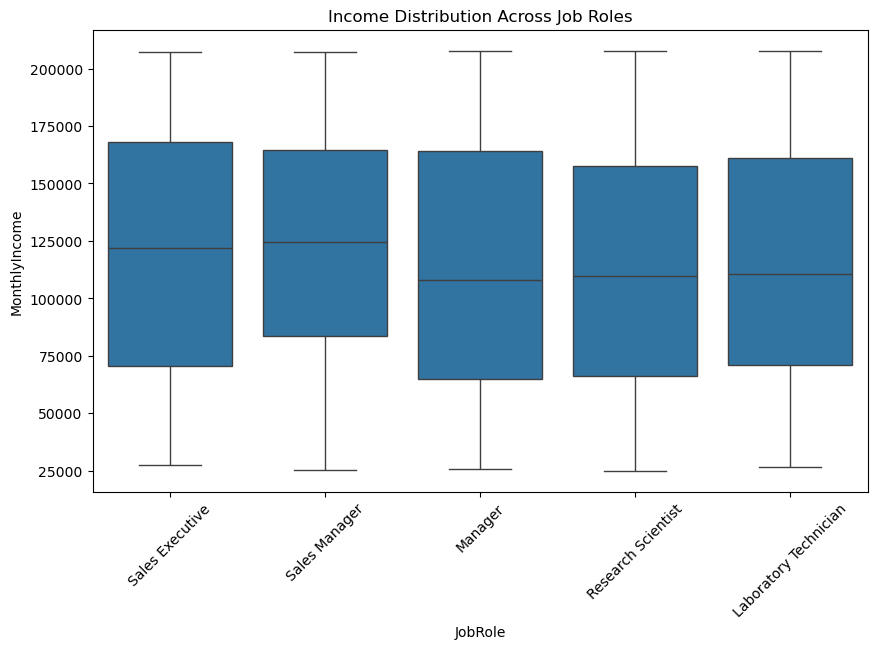

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="JobRole", y="MonthlyIncome", data=df_churn)
plt.xticks(rotation=45)
plt.title("Income Distribution Across Job Roles")
plt.show()


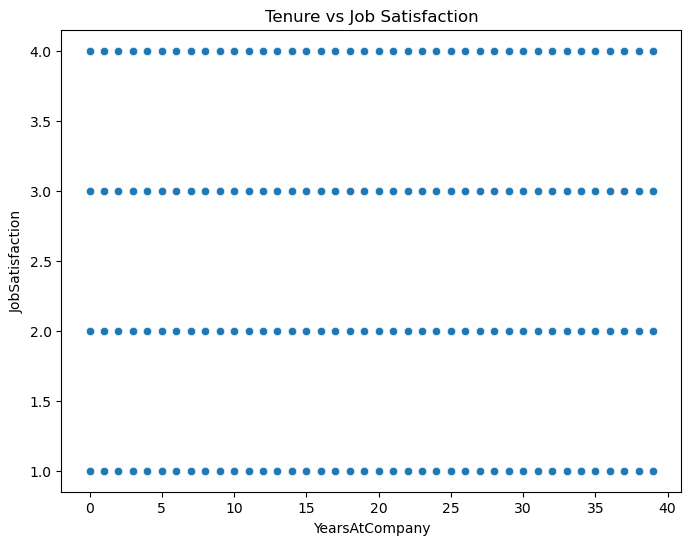

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="YearsAtCompany",y="JobSatisfaction",data=df_churn)
plt.title("Tenure vs Job Satisfaction")
plt.show()

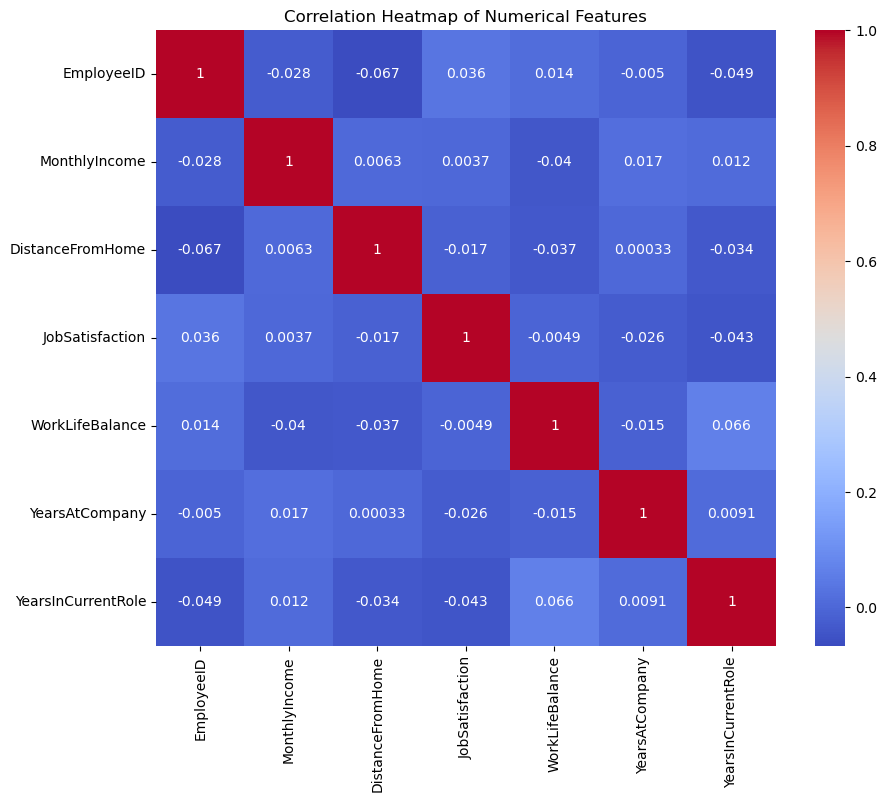

In [35]:
plt.figure(figsize=(10, 8))

numerical_df = df_churn.select_dtypes(include="number")
correlation = numerical_df.corr()

sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 2. Create a function that:
## Calculates churn percentage
### Identifies job roles with highest employee turnover
### Uses Pandas groupby() for aggregation
#### Returns insights as a dictionary

In [42]:
def churn_percent(df_churn):
    insights={}
    total_emp=len(df_churn)
    churn_emp=df_churn[df_churn['AttritionFlag']=="Yes"].shape[0]
    churn_percentage=(churn_emp/total_emp)*100
    insights[churn_percentage]=round(churn_percentage,2)
    churn_job=(df[df['AttritionFlag']=="Yes"].groupby("JobRole").size().sort_values(ascending=False))

    high_turnover_role=churn_job.index[0]
    high_turnover_count=churn_job.iloc[0]

    insights['Highest Role']=high_turnover_role
    insights['Turnover Count']=high_turnover_count
    return insights

# 3. Error handling:
## Validate data before visualization
## Handle missing values appropriately
## Use try-except for plotting operations
    

In [46]:
def visual_churn(df_churn):
    try:
        cols=["JobRole","MonthlyIncome","YearsAtCompany","JobSatisfaction"]
        for col in cols:
            if col not in df_churn.columns:
                raise ValueError(f"Missing column: {col}")
        df_churn_data=df_churn.dropna(subset=cols)
        plt.figure(figsize=(10, 6))
        sns.boxplot(x="JobRole", y="MonthlyIncome", data=df)
        plt.xticks(rotation=45)
        plt.title("Income Distribution Across Job Roles")
        plt.show()
    except ValueError as e:
        print("Data Error:",e)
        

# 4. Main execution:
## Generate all visualizations with proper labels and titles
### Display calculated insights
### Use NumPy for statistical measures
##### Dataset: employee_churn_database.csv

In [39]:
mean_income = np.mean(df["MonthlyIncome"])
std_income = np.std(df["MonthlyIncome"])

mean_satisfaction = np.mean(df["JobSatisfaction"])
std_satisfaction = np.std(df["JobSatisfaction"])

In [43]:
res=churn_percent(df_churn)
res

{16.75: 16.75,
 'Highest Role': 'Sales Executive',
 'Turnover Count': np.int64(49)}

In [44]:
print("Average_Income:",mean_income)
print("Standard_Income:",std_income)
print("Average _Satisfaction:",mean_satisfaction)
print("Standard_Satisfaction:",std_satisfaction)

Average_Income: 116348.1
Standard_Income: 53371.92599149531
Average _Satisfaction: 2.485
Standard_Satisfaction: 1.1223969885918264


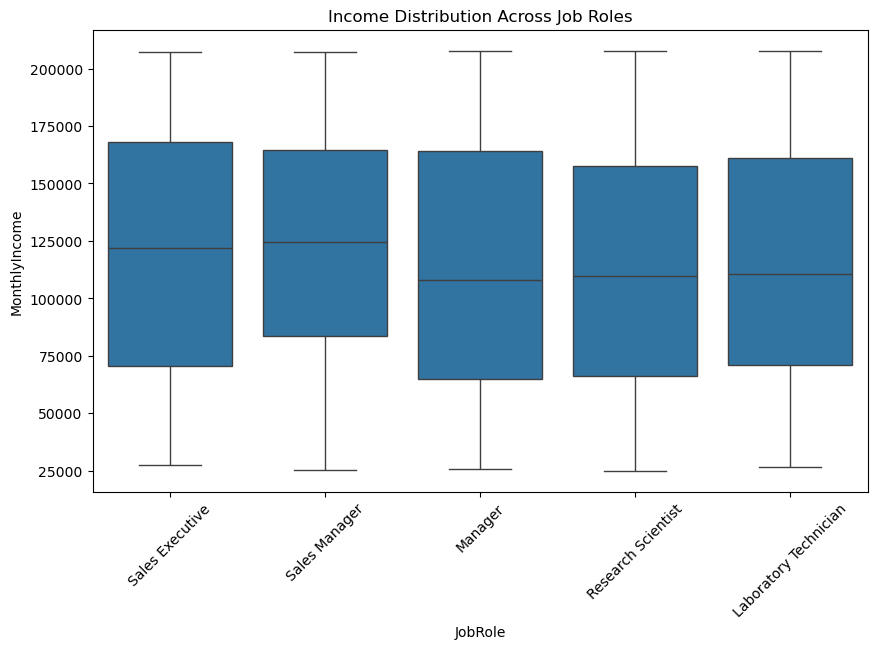

In [47]:
visual_churn(df_churn)

# Question 9 (10 Marks)
## Write a Python program with the following requirements:
## 1. Create a custom exception hierarchy with three levels:
### Base exception class
### Data validation exception
### Data processing exception

In [49]:
class DataError(Exception):
    pass
class DataValidationError(DataError):
    pass
class DataProcessingError(DataError):
    pass

## 2. Create an abstract base class with:
### Abstract method for validation
### Abstract method for data processing

In [50]:
from abc import ABC,abstractmethod

In [51]:
class DataHandler(ABC):
    @abstractmethod
    def validate(self,data):
        pass
    def process(self,data):
        pass

## 3. Implement concrete classes:
## Class 1: Data validator that:
### Validates CSV data
### Checks required fields and data types
### Validates value ranges
### Raises appropriate exceptions for invalid records
#### Uses try-except-finally for completeness
#### Implements both abstract methods

In [52]:
class CSVDataValidator(DataHandler):
    def validate(self,record):
        try:
            cols=['EmployeeID','Age','Salary']
            for col in cols:
                if col not in record or record[col]=="":
                    raise DataValidationError(f"Missing Required Cols: {col}")
            
            record["EmployeeID"] = int(record["EmployeeID"])
            record["Age"] = int(record["Age"])
            record["Salary"] = float(record["Salary"])

            if record["Age"] < 18 or record["Age"] > 60:
                raise DataValidationError("Age must be between 18 and 60")

            if record["Salary"] <= 0:
                raise DataValidationError("Salary must be positive")

            return True
            
        except ValueError:
            raise DataValidationError("Invalid data type detected")

        finally:
            pass

    def process(self, record):
        try:
            if self.validate(record):
                return {
                    "EmployeeID": record["EmployeeID"],
                    "Age": record["Age"],
                    "Salary": record["Salary"]
                }

        except DataValidationError as e:
            raise DataProcessingError(f"Processing failed: {e}")

## Class 2: Data integrator that:
### Loads multiple CSV files
### Validates relationships between datasets
### Raises exceptions if data integrity issues found
### Merges datasets using specified keys
### Implements encapsulation with private methods

In [53]:
class CSVDataIntegrator(DataHandler):
    def __init__(self):
        self.__datasets=[]
    def load_csv(self,manager_database):
        try:
            df_emp=pd.read_csv("manager_database(in).csv")
            return df
        except FileNotFoundError:
            raise DataProcessingError(f"File not Found: {"manager_database(in).csv"}")
        except Exception as e:
            raise DataProcessingError(f"Error Loading File {e}")

    def validate(self,df_list):
        try:
            for d in df_list:
                if not isinstance(df, pd.DataFrame):
                    raise DataValidationError("Invalid dataset type")
            
            for df in df_list:
                if "EmployeeID" not in df.columns:
                    raise DataValidationError("Missing 'EmployeeID' in dataset")

            return True

        except DataValidationError as e:
            raise
        except Exception as e:
            raise DataProcessingError(f"Validation error: {e}")

    def process(self, file_paths, merge_key="EmployeeID"):
        df_list = [self.__load_csv(fp) for fp in file_paths]
        self.validate(df_list)

        merged_df = df_list[0]
        for df in df_list[1:]:
            merged_df = pd.merge(merged_df, df, on=merge_key, how="inner")

        return merged_df

# 4. Main execution:
## Load and validate data with multiple exception types
### Merge datasets with error handling
### Display summary and error reports
##### Dataset: employee_database.csv, manager_database.csv

In [54]:
employee_file = "employee_database(in).csv"
manager_file = "manager_database(in).csv"

validator = CSVDataValidator()
integrator = CSVDataIntegrator()

error_log = []
try:
    employee_df = pd.read_csv(employee_file)
    manager_df = pd.read_csv(manager_file)
    for idx, row in employee_df.iterrows():
        try:
            validator.process(row)
        except DataError as ve:
            error_log.append(f"Employee ID {row['EmployeeID']}: {ve}")

    for idx, row in manager_df.iterrows():
        try:
            validator.process(row)
        except DataError as ve:
            error_log.append(f"Manager ID {row['EmployeeID']}: {ve}")

    merged_df = integrator.process([employee_file, manager_file], merge_key="EmployeeID")

    print("Merged Dataset Summary:")
    print(merged_df.info())
    print(merged_df.head())

except FileNotFoundError as fe:
    print("File not found:", fe)

except DataProcessingError as dpe:
    print("Data processing error:", dpe)

except DataValidationError as dve:
    print("Data validation error:", dve)

except DataError as de:
    print("General data error:", de)

except Exception as e:
    print("Unexpected error:", e)

finally:
    if error_log:
        print("\nError Report:")
        for err in error_log:
            print(err)
    else:
        print("\nNo validation errors found.")

Unexpected error: 'EmployeeID'

No validation errors found.


# Question 10 (10 Marks)
# Write a Python program that builds a comprehensive data analysis system with the following requirements:
## 1. Create a main analysis class that:
### Accepts file paths in constructor
### Has private methods for:
#### Loading data with exception handling
#### Cleaning data (missing values, type conversion)
#### Validating data integrity

### Has public methods for:
### Method 1: Churn analysis
#### Groups data across multiple dimensions
#### Returns comprehensive analysis as dictionary
#### Uses Pandas groupby() and aggregation

### Method 2: Metrics correlation
#### Merges all three datasets
#### Calculates correlation between variables
#### Uses NumPy for correlation matrix
#### Returns results

### Method 3: Visualizations
### Creates 4 different charts:
#### Department-level analysis (Bar chart)
#### Salary comparison (Box plot)
#### Work-life metrics analysis (Scatter)
#### Correlation visualization (Heatmap)
#### Uses Matplotlib and Seaborn
#### Includes error handling

### Method 4: Report generation
#### Consolidates all analysis
#### Returns formatted report
#### Includes statistics and insights

## 2. Exception handling:
### Custom exception for pipeline errors
### Try-except in all operations
### Graceful error recovery

## 3. Main execution:
### Initialize with all three datasets
### Execute complete analysis
### Generate final report containing:
### Overall statistics
### Top analysis insights
### Correlation findings
### Data quality summary
### Display all visualizations
### Handle data inconsistencies
##### Dataset: employee_database.csv, manager_database.csv, employee_churn_database.cs